### 1.Load data

In [ ]:
import scanpy as sc # cross celltype predict
import scresid
# import pertpy as pt # download dataset
import warnings
warnings.filterwarnings('ignore')
adata = sc.read_h5ad('./data/COVID.h5ad')
adata

AnnData object with n_obs × n_vars = 62509 × 16299
    obs: 'Collection_Day', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', 'author_cell_type', 'organism', 'sex', 'tissue', 'ethnicity', 'disease', 'assay', 'cell_type', 'dataset_group'
    var: 'gene_id', 'gene_name'
    uns: 'log1p', 'umap'
    obsm: 'X_scVI', 'X_umap'

In [ ]:
adata = scresid.adata_process(adata, 
                      # n_top_genes=2000
                      )

In [3]:
adata.obs.rename(columns={"Status": "condition"}, inplace=True) # COVID
adata.obs["condition"].replace({"Healthy": "control"}, inplace=True)
adata.obs['condition'].replace({"Covid": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"LPS": "stimulated"}, inplace=True)

In [4]:
adata = sc.AnnData(adata.X, obs=adata.obs.copy(), var=adata.var.copy())
adata.obs_names_make_unique()
print(adata)
print('\n', adata.obs['condition'].value_counts())
print('\n', adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 62509 × 6000
    obs: 'Collection_Day', 'Swab_result', 'condition', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', 'author_cell_type', 'organism', 'sex', 'tissue', 'ethnicity', 'disease', 'assay', 'cell_type', 'dataset_group', 'n_genes', 'n_counts'
    var: 'gene_id', 'gene_name', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

 condition
stimulated    50719
control       11790
Name: count, dtype: int64

 cell_type
CD16-positive, CD56-dim natural killer cell, human       8566
CD14-positive monocyte                                   7986
central memory CD4-positive, alpha-beta T cell           6564
naive thymus-derived CD4-positive, alpha-beta T cell     6184
naive B cell                                             5369
effector CD8-positive, alpha-beta T cell                 4169
naive thy

### 2.Build and train models

In [5]:
model = scresid.SCRESID(input_dim=adata.n_vars, device='cuda:0')
model = model.to(model.device)
# key_dic varies with the adata
key_dic = {'condition_key': 'condition',
           'cell_type_key': 'cell_type',
           'ctrl_key': 'control',
           'stim_key': 'stimulated',
           'pred_key': 'predict',
           }


In [ ]:
cell_to_pred = 'CD16-positive, CD56-dim natural killer cell, human' # CD14-positive monocyte, central memory CD4-positive, alpha-beta T cell
# The training set does not contain the type of data to be predicted after the perturbation
train = adata[~((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
               (adata.obs[key_dic['condition_key']] == key_dic['stim_key']))]
model.train_SCRESID(train, batch_size=256, lr=5e-5, epochs=100)

Training Epoch 99: 100%|██████████| 100/100 [05:28<00:00,  3.28s/it]


### 3.Predict

In [7]:
adata_to_pred = adata[((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
                       (adata.obs[key_dic['condition_key']] == key_dic['ctrl_key']))]
pred = model.predict(train_adata=train,
                     cell_to_pred=cell_to_pred,
                     key_dic=key_dic,
                     ratio=0.03 # The ratio need to vary with the size of dataset
                     )  
print(pred)

Get adata of CD16-positive, CD56-dim natural killer cell, human and control...
Get adata of without CD16-positive, CD56-dim natural killer cell, human and control...
Get stimulated adata of condition...
Get latent adata of control and stimulated...
Compute distance of stimulated and control by POT...
Compute G of stimulated and control by emd in POT...
Match max idx from G...
Get delta list of matched stimulated and control...
Get latent adata of CD16-positive, CD56-dim natural killer cell, human...
Compute cosine similarity with latent adata of CD16-positive, CD56-dim natural killer cell, human and control...
Select top control with ratio 0.03...
Normalize weights of 303 top cosine similarity...
Compute delta of predict...
Decode predict latent embedding...
Create predict adata and save key predict...
Predict process completed.
AnnData object with n_obs × n_vars = 1709 × 6000
    obs: 'Collection_Day', 'Swab_result', 'condition', 'Smoker', 'Status_on_day_collection', 'Status_on_day_co

### 4.Evaluation

PCA cluster results...


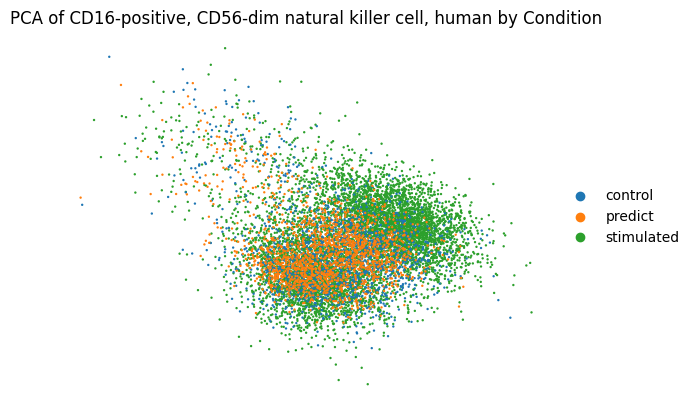

Compute rank_genes_groups...
Select common DEGS...
Common DEGs:  0
Regression plot of mean...


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


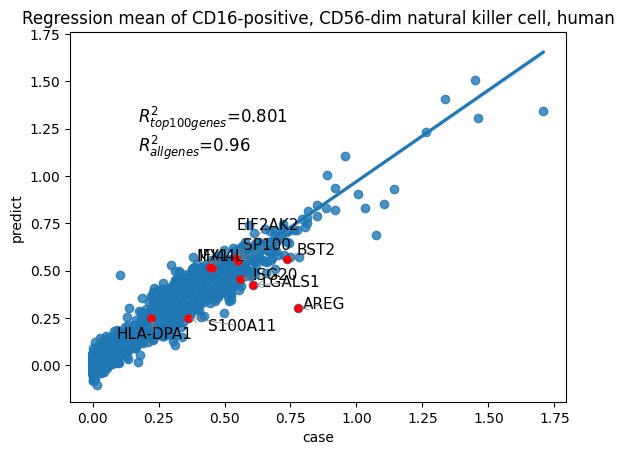

R2 mean of all genes 0.96, top genes 0.801
Regression plot of var...


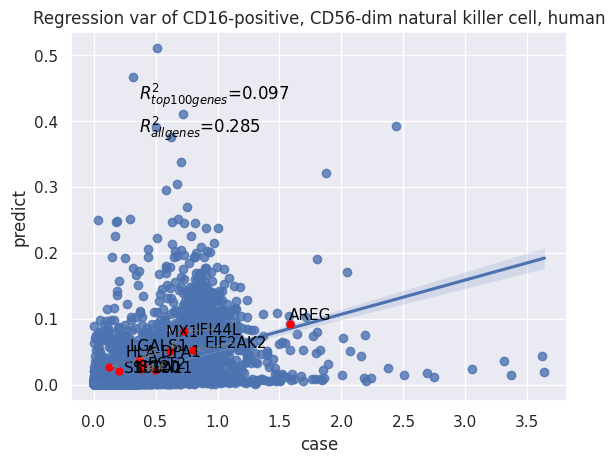

R2 var of all genes 0.285, top genes 0.097
Plot violin graph of first gene ISG20...


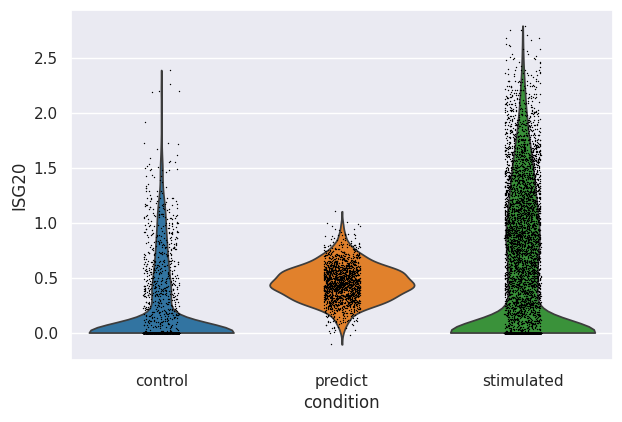

Plot violin graph of second gene LGALS1...


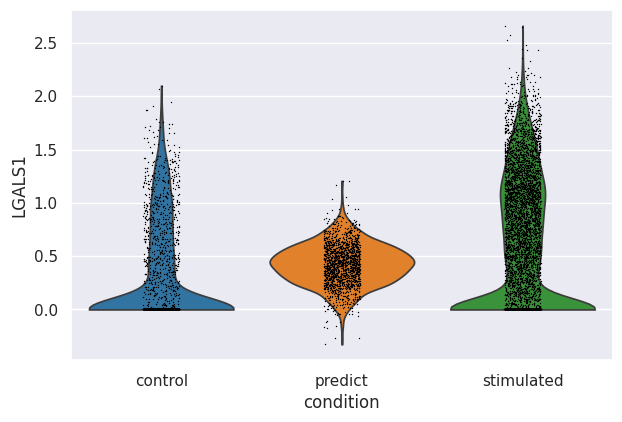

Plot violin graph of third gene IFI44L...


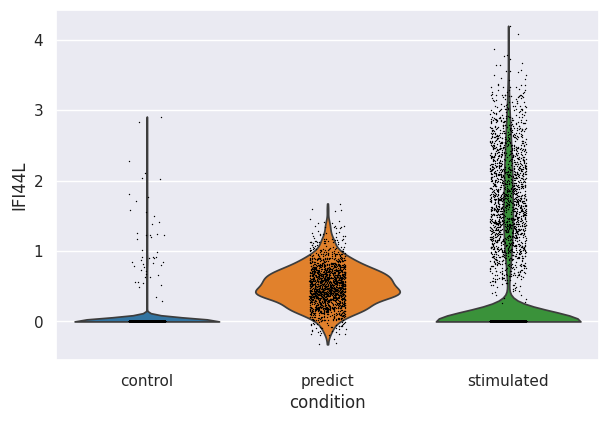

Compute DEGS contrast...
Plot 25 genes of eval_adata...


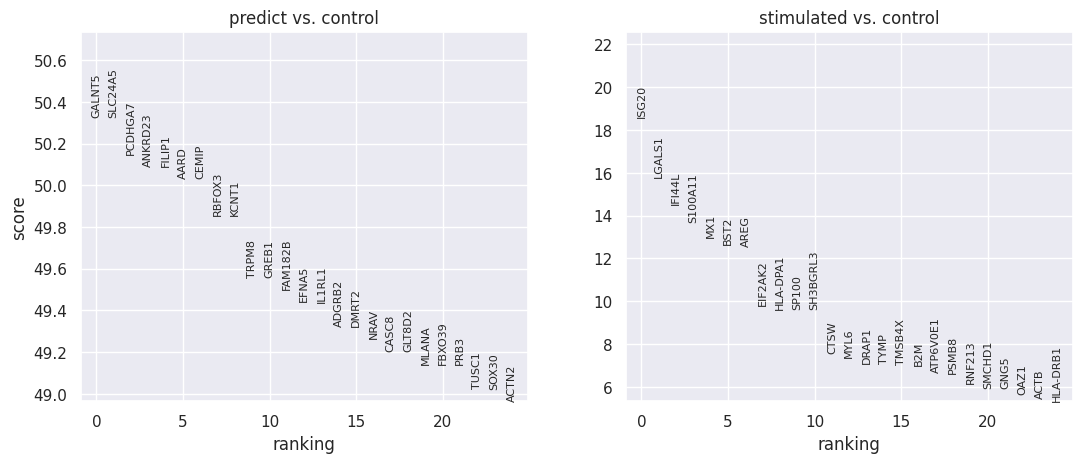

Dotplot of the first 20 genes...


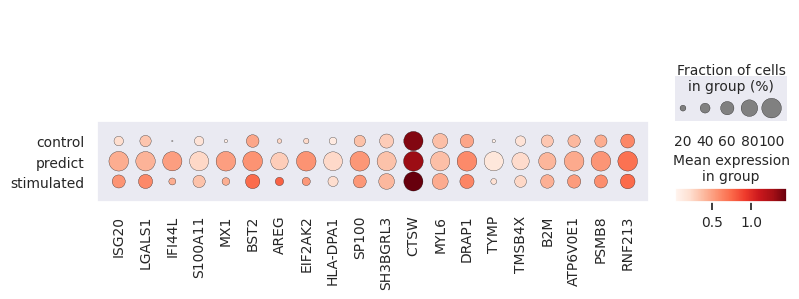

In [8]:
ground_truth = adata[(adata.obs[key_dic['cell_type_key']] == cell_to_pred)]
eval_adata = ground_truth.concatenate(pred)
scresid.evaluate(eval_adata=eval_adata, 
                cell_type=cell_to_pred, 
                key_dic=key_dic
                )
